In [22]:
from __future__ import annotations

import numpy as np

import torch
import torch.nn as nn

from scipy.sparse.linalg import svds

from ordpy import ordinal_distribution, complexity_entropy
from nolds import lyap_r

from src.model import RosslerNet

import matplotlib.pyplot as plt


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

## Semantic Trajectories

In [ ]:
exp_name = 'rossler_14k_loss_rk5'

dt          = 0.01
Nbatch      = 10000
tepoch      = 100 
tvalid      = 3   
num_epochs  = 14000
hidden_size = 100 
transient_process = 10000

In [ ]:
mu_u = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32, device=device)
su   = torch.tensor([10.0, 10.0, 10.0], dtype=torch.float32, device=device)
mu_p = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32, device=device)
sp   = torch.tensor([10.0, 10.0, 10.0], dtype=torch.float32, device=device)
mu_g = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32, device=device)
sg   = torch.tensor([14.0, 101.0, 142.0], dtype=torch.float32, device=device)

In [ ]:
class RosslerNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(6, hidden_size)
        self.act = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_size, 3)

    def forward(self, u, p):

        u0 = (u - mu_u) / su
        p0 = (p - mu_p) / sp

        h  = self.act(self.fc1(torch.cat([u0, p0], dim=-1)))
        g  = self.fc2(h)

        d = dt * (g * sg + mu_g)
        return d

model = RosslerNet().to(device)

In [41]:
def get_traj(exp_name):

    a, b, c = 0.1, 0.1, 6.

    t0, t1, dt_vis = 0.0, 300.0, dt
    t_eval = np.arange(t0, t1+dt_vis, dt_vis)
    y0 = np.array([1.0, 1.0, 1.0], dtype=np.float32)


    model.load_state_dict(torch.load(f'ckpt/{exp_name}.pt', map_location=device))
    model.to(device).eval()

    us = torch.empty((len(t_eval), 3), device=device)
    u = torch.tensor(y0, device=device)
    p = torch.tensor([a, b, c], dtype=torch.float32, device=device)

    with torch.no_grad():
        for i in range(len(t_eval)):
            us[i] = u
            d = model(u.unsqueeze(0), p.unsqueeze(0)).squeeze(0)
            u = u + d

    u_model = us.cpu().numpy()
    
    return u_model

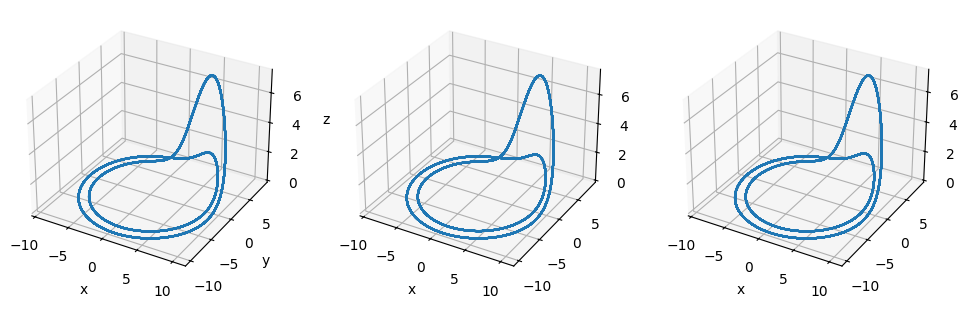

In [44]:
exp_name = 'rossler_14k_loss_rk2'
u_model_rk2 = get_traj(exp_name)

exp_name = 'rossler_14k_loss_rk4'
u_model_rk4 = get_traj(exp_name)

exp_name = 'rossler_14k_loss_rk5'
u_model_rk5 = get_traj(exp_name)


fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')

ax1.plot(u_model_rk2[:,0][transient_process:], u_model_rk2[:,1][transient_process:], u_model_rk2[:,2][transient_process:], label='Model')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')


ax2.plot(u_model_rk4[:,0][transient_process:], u_model_rk4[:,1][transient_process:], u_model_rk4[:,2][transient_process:], label='Model')
ax2.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')


ax3.plot(u_model_rk5[:,0][transient_process:], u_model_rk5[:,1][transient_process:], u_model_rk5[:,2][transient_process:], label='Model')
ax3.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

plt.show()

In [45]:
ce_trajectory_rk2 = complexity_entropy(u_model_rk2, dx=3, probs=False)

ce_trajectory_rk4 = complexity_entropy(u_model_rk4, dx=3, probs=False)

ce_trajectory_rk5 = complexity_entropy(u_model_rk5, dx=3, probs=False)

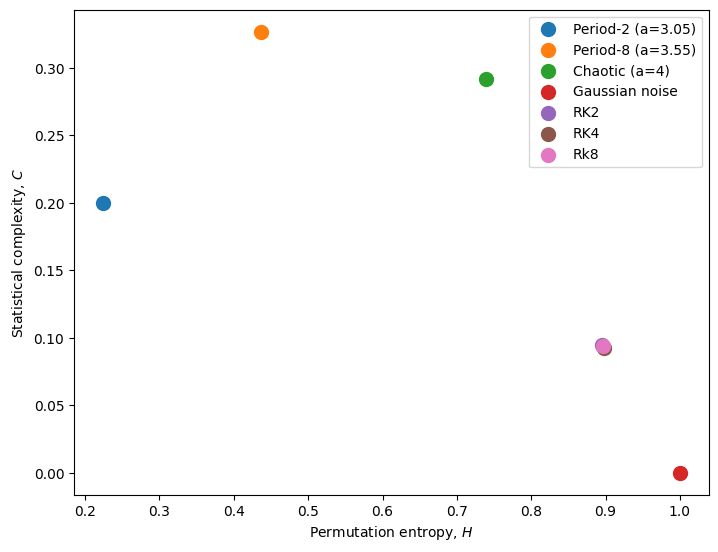

In [47]:
import numpy as np
import ordpy
from matplotlib import pylab as plt

def logistic(a=4, n=100000, x0=0.4):
    x = np.zeros(n)
    x[0] = x0
    for i in range(n - 1):
        x[i + 1] = a * x[i] * (1 - x[i])
    return(x)

f, ax = plt.subplots(figsize=(8.19, 6.3))

time_series = [logistic(a) for a in [3.05, 3.55, 4]]
time_series += [np.random.normal(size=100000)]
HC = [ordpy.complexity_entropy(series, dx=4) for series in time_series]
for HC_, label_ in zip(HC, ['Period-2 (a=3.05)',
                            'Period-8 (a=3.55)',
                            'Chaotic (a=4)',
                            'Gaussian noise']):
    ax.scatter(*HC_, label=label_, s=100)

ax.scatter(*ce_trajectory_rk2, label='RK2', s=100)
ax.scatter(*ce_trajectory_rk4, label='RK4', s=100)
ax.scatter(*ce_trajectory_rk5, label='Rk8', s=100)

ax.set_xlabel('Permutation entropy, $H$')
ax.set_ylabel('Statistical complexity, $C$')

ax.legend();